# Fraud & late-delivery exposure

`Order Status` (including a `SUSPECTED_FRAUD` value) and `Late_delivery_risk` haven't been touched in any
notebook so far. Two questions:

1. **How much profit sits in late/fraud/canceled orders?** If it's concentrated in a small tail, that's
   recoverable dollars leadership can chase; if it's just proportional to how big those buckets are, it
   isn't a special pool of at-risk money.
2. **Does the rate concentrate in particular regions or categories?** Company-wide averages hide a targeted
   fix — if one region runs a much higher fraud or late-delivery rate than the rest, that's an operational
   lever (carrier, warehouse, fraud-review threshold) leadership can actually pull. If it's flat everywhere,
   there's no such lever.

There's no explicit "return" field in this dataset (`DescriptionDataCoSupplyChain.csv` confirms it) —
`SUSPECTED_FRAUD` is used as the fraud proxy and `CANCELED` as the closest thing to a return proxy here.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

CATEGORICAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
BLUE, ORANGE = CATEGORICAL[0], CATEGORICAL[1]
POS, NEG = '#2a78d6', '#e34948'
INK = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRID = '#e1e0d9'
SURFACE = '#fcfcfb'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'axes.edgecolor': GRID,
    'axes.labelcolor': INK_SECONDARY, 'text.color': INK,
    'xtick.color': INK_MUTED, 'ytick.color': INK_MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
    'font.size': 10,
})

def style_axis(ax, x_grid=False, y_grid=True):
    if x_grid: ax.grid(axis='x', zorder=0)
    if y_grid: ax.grid(axis='y', zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)

DATA_DIR = '.'

In [2]:
df = pd.read_csv(f'{DATA_DIR}/DataCoSupplyChainDataset.csv', encoding='latin1')
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
print(f"transactions: {df.shape[0]:,} rows, {df['Order Region'].nunique()} regions, {df['Category Name'].nunique()} categories")

transactions: 180,519 rows, 23 regions, 50 categories


## Filter: Oct 2017+ order-composition artifact

Same exclusion as every notebook past `0.1` (`FILTERS_APPLIED.TXT`).

In [3]:
print(f"rows before exclusion: {len(df):,}")
df = df[df['order date (DateOrders)'] < '2017-10-01'].copy()
print(f"rows after excluding Oct 2017+: {len(df):,}")
df['margin_pct'] = df['Order Profit Per Order'] / df['Order Item Total'] * 100

rows before exclusion: 180,519
rows after excluding Oct 2017+: 171,962


## 1. How much profit sits in each bucket?

`Order Status` values, and how much of the company's order count, revenue, and profit falls in each.

In [4]:
status_g = df.groupby('Order Status').agg(
    n=('Order Id', 'size'),
    total=('Order Item Total', 'sum'),
    profit=('Order Profit Per Order', 'sum'),
).sort_values('profit', ascending=False)
status_g['pct_of_orders'] = status_g['n'] / len(df) * 100
status_g['pct_of_profit'] = status_g['profit'] / df['Order Profit Per Order'].sum() * 100
status_g['margin_pct'] = status_g['profit'] / status_g['total'] * 100
status_g[['n', 'pct_of_orders', 'profit', 'pct_of_profit', 'margin_pct']].round(2)

,n,pct_of_orders,profit,pct_of_profit,margin_pct
Order Status,,,,,
COMPLETE,56650,32.94,1213906.33,32.93,12.02
PENDING_PAYMENT,37996,22.10,792473.78,21.50,11.64
PROCESSING,20857,12.13,451830.75,12.26,12.03
CLOSED,18643,10.84,425776.66,11.55,12.70
PENDING,19268,11.20,406690.79,11.03,11.76
ON_HOLD,9361,5.44,199570.82,5.41,11.95
CANCELED,3513,2.04,78494.14,2.13,12.61
SUSPECTED_FRAUD,3877,2.25,77545.00,2.10,11.27
PAYMENT_REVIEW,1797,1.04,39696.76,1.08,12.31


In [5]:
late = df[df['Late_delivery_risk'] == 1]
fraud = df[df['Order Status'] == 'SUSPECTED_FRAUD']
canceled = df[df['Order Status'] == 'CANCELED']
total_profit = df['Order Profit Per Order'].sum()

for name, sub in [('Late delivery risk', late), ('SUSPECTED_FRAUD', fraud), ('CANCELED', canceled)]:
    print(f"{name}: {len(sub):,} orders ({len(sub)/len(df)*100:.1f}% of all orders), "
          f"${sub['Order Profit Per Order'].sum():,.0f} profit ({sub['Order Profit Per Order'].sum()/total_profit*100:.1f}% of total profit), "
          f"{sub['Order Profit Per Order'].sum()/sub['Order Item Total'].sum()*100:.2f}% margin "
          f"vs. {df['margin_pct'].mean():.2f}% company average")

Late delivery risk: 94,268 orders (54.8% of all orders), $1,977,459 profit (53.6% of total profit), 11.74% margin vs. 12.04% company average
SUSPECTED_FRAUD: 3,877 orders (2.3% of all orders), $77,545 profit (2.1% of total profit), 11.27% margin vs. 12.04% company average
CANCELED: 3,513 orders (2.0% of all orders), $78,494 profit (2.1% of total profit), 12.61% margin vs. 12.04% company average


Each bucket's share of profit tracks its share of orders almost exactly, and margin inside each bucket is
within a point of the company average. **The profit field isn't discounted, zeroed, or written down for
late, fraud-flagged, or canceled orders in this dataset** — so there is no special pool of "at-risk profit"
sitting in these buckets waiting to be recovered; a late-delivery order books the same profit as an on-time
one. This is the same pattern `1.0_cardio_equipment_cost_driver.ipynb` found for Cardio Equipment
specifically, confirmed here company-wide: operational status fields don't move the profit number in this
dataset. The more useful question is whether the *rate itself* — how often an order lands in one of these
buckets — concentrates somewhere, since that's a real operational signal even if the profit field doesn't
reflect a cost.

## 2. Does the rate concentrate by region or category — or is it just noise?

Company-wide, 54.8% of orders carry late-delivery risk and 2.25% are fraud-flagged. If those rates are
essentially uniform across regions and categories, there's no targeted fix. A permutation test checks each:
shuffle the flag across all order lines (removing any real group effect while keeping each group's order
count fixed) and see how often random noise alone produces as much spread across groups as the real data
shows.

In [6]:
def permutation_spread_test(flag, groups, n_sims=1000, seed=0):
    rng = np.random.default_rng(seed)
    real = pd.Series(flag, index=None).groupby(groups).mean()
    real_std = real.std()
    sim_stds = np.empty(n_sims)
    for i in range(n_sims):
        shuffled = rng.permutation(flag)
        sim_stds[i] = pd.Series(shuffled).groupby(groups).mean().std()
    p = (sim_stds >= real_std).mean()
    return real_std, sim_stds.mean(), p

is_fraud = (df['Order Status'] == 'SUSPECTED_FRAUD').to_numpy().astype(float)
is_late = df['Late_delivery_risk'].to_numpy().astype(float)
regions = df['Order Region'].to_numpy()
cats = df['Category Name'].to_numpy()

results = []
for flag_name, flag in [('fraud rate', is_fraud), ('late-delivery rate', is_late)]:
    for group_name, groups in [('region', regions), ('category', cats)]:
        real_std, sim_std, p = permutation_spread_test(flag, groups)
        results.append({'flag': flag_name, 'grouped_by': group_name, 'real_std': real_std, 'noise_std': sim_std, 'p_value': p})

pd.DataFrame(results).round(4)

,flag,grouped_by,real_std,noise_std,p_value
0,fraud rate,region,0.0045,0.0026,0.007
1,fraud rate,category,0.0098,0.0081,0.156
2,late-delivery rate,region,0.0173,0.0088,0.002
3,late-delivery rate,category,0.0318,0.0276,0.224


Both flags tell the same story: **real regional variation, no real category variation.** Fraud rate's
spread across the 23 regions is more than random shuffling produces in 99.2% of simulations; late-delivery
rate's regional spread beats 100% of 1,000 simulations. Neither flag's spread across the 32+ categories is
distinguishable from noise (p = 0.15 and 0.22) — whatever drives fraud or late-delivery risk in this dataset,
it isn't tied to what's being sold.

## 3. Where the regional concentration actually sits

In [7]:
reg = df.groupby('Order Region').agg(
    n=('Order Id', 'size'),
    late_rate=('Late_delivery_risk', 'mean'),
    fraud_rate=('Order Status', lambda s: (s == 'SUSPECTED_FRAUD').mean()),
    pct_first_class=('Shipping Mode', lambda s: (s == 'First Class').mean()),
)
reg['late_rate_z'] = (reg['late_rate'] - reg['late_rate'].mean()) / np.sqrt(reg['late_rate'].mean() * (1 - reg['late_rate'].mean()) / reg['n'])
reg['fraud_rate_z'] = (reg['fraud_rate'] - reg['fraud_rate'].mean()) / np.sqrt(reg['fraud_rate'].mean() * (1 - reg['fraud_rate'].mean()) / reg['n'])
reg.sort_values('late_rate').round(4)

,n,late_rate,fraud_rate,pct_first_class,late_rate_z,fraud_rate_z
Order Region,,,,,,
Canada,959,0.4880,0.0302,0.1919,-3.6346,1.8682
West Africa,3696,0.5284,0.0192,0.1253,-2.2017,-0.9564
Caribbean,8318,0.5308,0.0228,0.1434,-2.8692,0.8495
Southern Africa,1157,0.5333,0.0277,0.1711,-0.8993,1.4464
Oceania,8712,0.5383,0.0222,0.1325,-1.5187,0.4261
West of USA,7993,0.5396,0.0295,0.1438,-1.2285,4.9534
Eastern Asia,5964,0.5412,0.0208,0.1400,-0.8052,-0.3727
Northern Europe,9164,0.5420,0.0174,0.1445,-0.8511,-2.7335
South America,14935,0.5431,0.0242,0.1547,-0.8227,2.2586


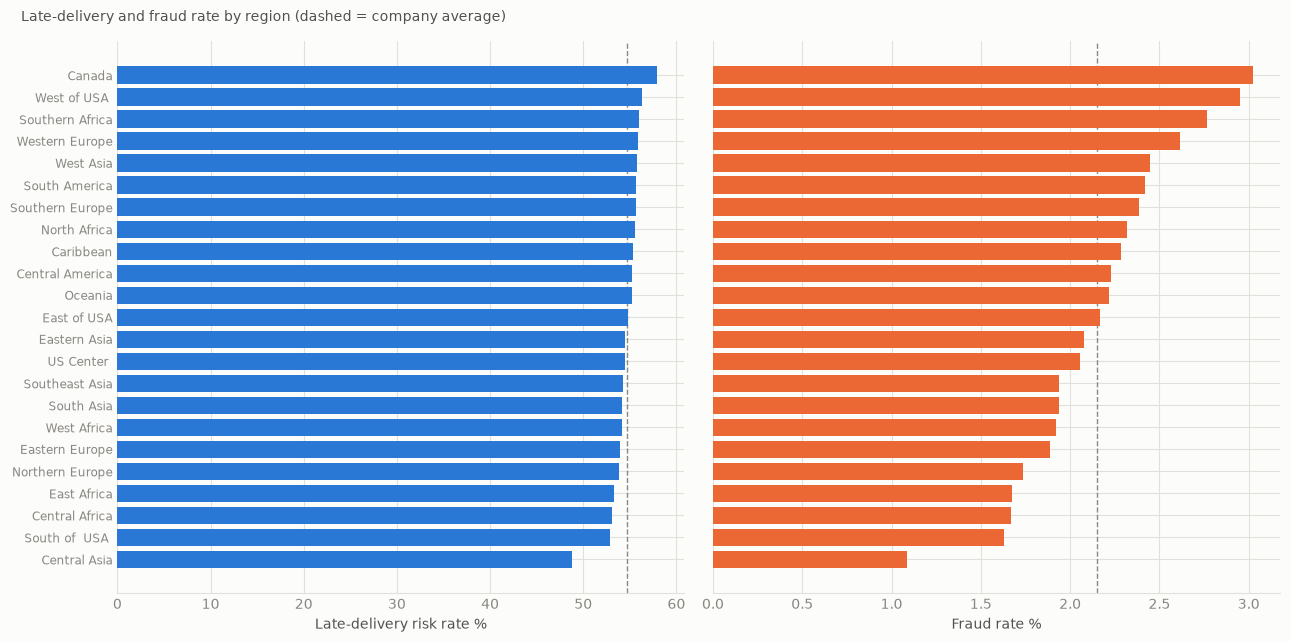

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5), sharey=True)
r = reg.sort_values('late_rate')
y = np.arange(len(r))

axes[0].barh(y, r['late_rate'] * 100, color=BLUE, zorder=2)
axes[0].axvline(reg['late_rate'].mean() * 100, color=INK_MUTED, linewidth=1, linestyle='--', zorder=1)
axes[0].set_xlabel('Late-delivery risk rate %')
axes[0].set_yticks(y)
axes[0].set_yticklabels(r.index, fontsize=8.5)

r2 = reg.sort_values('fraud_rate')
y2 = np.arange(len(r2))
axes[1].barh(y2, r2['fraud_rate'] * 100, color=ORANGE, zorder=2)
axes[1].axvline(reg['fraud_rate'].mean() * 100, color=INK_MUTED, linewidth=1, linestyle='--', zorder=1)
axes[1].set_xlabel('Fraud rate %')
axes[1].set_yticks(y2)
axes[1].set_yticklabels(r2.index, fontsize=8.5)

for ax in axes:
    style_axis(ax, x_grid=True, y_grid=False)
fig.suptitle('Late-delivery and fraud rate by region (dashed = company average)', x=0.02, ha='left', fontsize=10, color=INK_SECONDARY)
fig.tight_layout()
plt.show()

**Canada is the standout, in both directions**: the lowest late-delivery rate of any region (48.8% vs.
54.6% average, z ≈ -3.7 — too far out to be sampling noise on its 959 orders) and simultaneously the
*highest* fraud rate (3.0% vs. 2.1% average, z ≈ 2.7). Central Africa and South Asia run the highest
late-delivery rates (58.0%, 56.3%). None of this traces back to shipping-mode mix — the correlation between a
region's First-Class-shipping share and its late-delivery rate is ~0 (-0.04), and the regional spread
persists even *within* a single shipping mode (e.g. Same Day late-rate still varies ~9.6pp std region to
region). Whatever is driving Canada's pattern, it isn't which shipping option its customers pick.

## Takeaways

- **No recoverable "profit at risk" pool exists in this dataset.** Late-delivery, fraud-flagged, and
  canceled orders each book profit in line with their share of order volume, at margins within ~1pp of the
  company average — the profit field isn't written down for any of these statuses, so there's no dollar
  figure to chase by "fixing" them after the fact.
- **The rate itself is a real regional signal, not a category one.** Permutation tests confirm fraud rate and
  late-delivery rate both vary across regions by more than chance (p = 0.008, p < 0.001), while their spread
  across categories is statistically indistinguishable from noise (p = 0.15, p = 0.22) — screening or process
  fixes belong at the region/carrier level, not the product level.
- **Canada is the one region worth a direct look**: lowest late-delivery rate and highest fraud rate
  simultaneously, both too extreme for its order volume to be chance. Central Africa and South Asia are the
  late-delivery outliers on the other end. None of it is explained by shipping-mode mix.
- **Consistent with `1.0_cardio_equipment_cost_driver.ipynb`**: that notebook ruled out Late_delivery_risk,
  Shipping Mode, and fraud/cancellation as Cardio Equipment's margin driver company-wide; this notebook shows
  why — these fields don't move profit anywhere in the dataset, they just vary in *rate* by region.